<a href="https://colab.research.google.com/github/Lsa323/HISPA/blob/main/Medical_LLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#main component of treatment
import numpy as np
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
#Copy of GeneralSurgery2
file_path = "/content/drive/MyDrive/TheGeneralSurgery2.xlsx"
df = pd.read_excel(file_path,header=1)

In [ ]:
#creation of the text oriented dataset
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# Concatenate all text columns into a single 'FullText' column
text_columns = ["Diagnosis", "ClinicalCourse", "Investigations", "Surgery", "Problems","PlanonDischarge", "SOPDFollowUp", "DischargeMedication"]
# Fill NaN with empty strings to avoid errors during concatenation
df[text_columns] = df[text_columns].fillna("")

In [ ]:
#merge all the text required
# Create the new column combining all the text fields
df["FullText"] = df[text_columns].agg(". ".join, axis=1)

In [ ]:
import pandas as pd

def add_readmission_label(df, text_column='FullText'):
    complication_keywords = [
        "sepsis", "pneumonia", "respiratory distress", "tachycardia", "hypotension",
        "acidosis", "renal failure", "stroke", "deteriorated", "cardiac arrest",
        "bleeding", "wound infection", "nosocomial", "readmitted", "complicated", "died",
        "desaturation", "reintubation", "sirs", "intubated", "decompensated", "unstable"
    ]

    stability_keywords = [
        "stable", "recovered well", "no complications", "doing well", "uneventful",
        "hemodynamically stable", "clean wound", "mobilizing", "no signs of infection",
        "pain controlled", "tolerating diet", "improved", "vitals normal", "no issue"
    ]

    def count_keywords(text, keywords):
        return sum(1 for kw in keywords if kw.lower() in text.lower())

    levels = []

    for note in df[text_column]:
        comp = count_keywords(note, complication_keywords)
        stab = count_keywords(note, stability_keywords)
        total = comp + stab

        if total == 0:
            level = 1  # medium by default if no keywords found
        else:
            pct = comp / total
            if pct <= 0.33:
                level = 0  # low risk
            elif pct <= 0.66:
                level = 1  # medium risk
            else:
                level = 2  # high risk

        levels.append(level)

    df = df.copy()
    df['readmitted'] = levels
    return df


In [ ]:
df_new = add_readmission_label(df)

In [ ]:
df_new['readmitted'].value_counts()

,count
readmitted,
0,10266
1,8991
2,2740


In [ ]:
#from the new readmission dataset we'll reserv some columns for model production especially for calssification
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.model_selection import train_test_split
import pandas as pd

tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
model = AutoModelForSequenceClassification.from_pretrained("emilyalsentzer/Bio_ClinicalBERT", num_labels=3)

# Tokenize
# Sample data for faster debugging
sampled_df = df_new.sample(1000, random_state=42)
encodings = tokenizer(list(sampled_df["FullText"]), truncation=True, padding=True, max_length=512)

# Format dataset
dataset = Dataset.from_dict({**encodings, "labels": sampled_df["readmitted"].tolist()})

# Convert dataset to pandas DataFrame before splitting
dataset_df = pd.DataFrame(dataset)


# Split dataset into training and evaluation sets
train_data, eval_data = train_test_split(dataset_df, test_size=0.2, random_state=42)

# Convert splits back to Dataset objects
train_dataset = Dataset.from_pandas(train_data)
eval_dataset = Dataset.from_pandas(eval_data)


# Trainer
trainer = Trainer(
    model=model,
    args=TrainingArguments(output_dir="./results", per_device_train_batch_size=8),
    train_dataset=train_dataset,
    eval_dataset=eval_dataset # Add the evaluation dataset here
)
trainer.train()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: mbalelandry (mbalelandry-unh) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss


Step,Training Loss


TrainOutput(global_step=300, training_loss=0.5678730265299479, metrics={'train_runtime': 14550.4259, 'train_samples_per_second': 0.165, 'train_steps_per_second': 0.021, 'total_flos': 631472202547200.0, 'train_loss': 0.5678730265299479, 'epoch': 3.0})

In [ ]:
trainer.evaluate()
#4143b1270c4e4b185cef2bee313f4146f55cf720

{'eval_loss': 0.42367127537727356,
 'eval_runtime': 335.3459,
 'eval_samples_per_second': 0.596,
 'eval_steps_per_second': 0.075,
 'epoch': 3.0}

In [ ]:
from sklearn.metrics import classification_report
# Supposons que tu as : eval_dataset et ton Trainer
predictions = trainer.predict(eval_dataset)
y_pred = predictions.predictions.argmax(axis=1)
y_true = predictions.label_ids

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0     0.8750    0.9231    0.8984        91
           1     0.8462    0.8370    0.8415        92
           2     0.7692    0.5882    0.6667        17

    accuracy                         0.8550       200
   macro avg     0.8301    0.7828    0.8022       200
weighted avg     0.8527    0.8550    0.8525       200



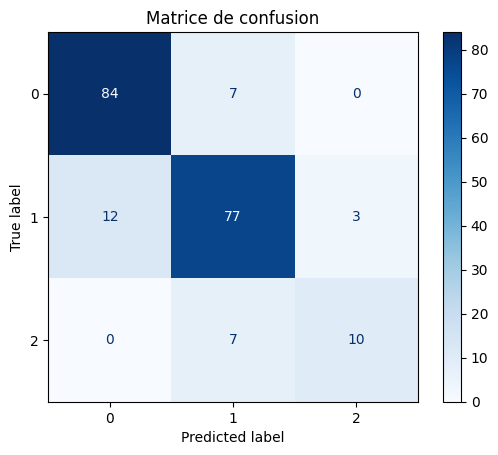

In [ ]:
#evaluation starting
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt
from transformers import Trainer

# Étape 1 : Prédictions
predictions = trainer.predict(eval_dataset)
y_true = predictions.label_ids
y_prob = predictions.predictions
y_pred = np.argmax(y_prob, axis=1)

# Étape 2 : Rapport complet
report = classification_report(y_true, y_pred, digits=4, output_dict=True)
print(classification_report(y_true, y_pred, digits=4))

# Étape 3 : Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Matrice de confusion")
plt.show()

# Étape 4 : ROC curve (si binaire)
if y_prob.shape[1] == 2:
    RocCurveDisplay.from_predictions(y_true, y_prob[:, 1])
    plt.title("Courbe ROC")
    plt.show()


In [ ]:
#starting traditionnal ML to have the best model for future federated learning
!pip install scikit-learn xgboost matplotlib seaborn joblib

In [ ]:
#use clinical BERT and Radom Forest
#Encoding function for 768 vector
def get_bert_embedding(text):
    with torch.no_grad():
        inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
        outputs = model(**inputs)
        # Use [CLS] token representation
        cls_embedding = outputs.last_hidden_state[:, 0, :]  # shape: (1, hidden_size)
        return cls_embedding.squeeze().numpy()


In [ ]:
#importation of torch
from transformers import AutoTokenizer, AutoModel
import torch

# Load pretrained model (without classification head)
tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
model = AutoModel.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
model.eval()  # set to evaluation mode

# Sample data
sampled_df = df_new.sample(1000, random_state=42)
# Embeddings generation
X = [get_bert_embedding(text) for text in sampled_df["FullText"]]
y = sampled_df["readmitted"].tolist()  # labels: 0, 1, 2


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Evaluate
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.54      0.75      0.62        91
           1       0.60      0.46      0.52        92
           2       0.67      0.12      0.20        17

    accuracy                           0.56       200
   macro avg       0.60      0.44      0.45       200
weighted avg       0.58      0.56      0.54       200



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Example dataset
# df = pd.read_csv("your_dataset.csv")
X_text = sampled_df["FullText"]
y = sampled_df["readmitted"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42)

# Choose a model: Random Forest or XGBoost
# model = RandomForestClassifier(n_estimators=100, random_state=42)
model = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)

# Pipeline: TF-IDF + Classifier
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ('clf', model)
])

# Train
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1] if hasattr(pipeline.named_steps['clf'], 'predict_proba') else None


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:12:06] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:
print(classification_report(y_test, y_pred, digits=4))


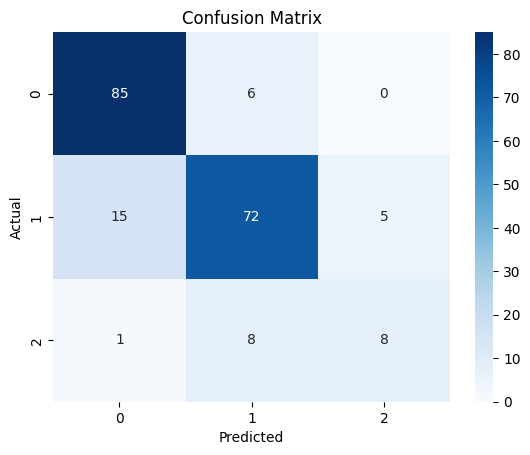

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
if y_proba is not None:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.2f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

ValueError: multiclass format is not supported

In [ ]:
# Sauvegarde du modèle et du tokenizer
trainer.save_model("my_saved_model")
tokenizer.save_pretrained("my_saved_model")


In [ ]:
import json

with open("classification_report.json", "w") as f:
    json.dump(report, f, indent=4)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Example dataset
# df = pd.read_csv("your_dataset.csv")
X_text = df["text"]
y = df["label"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42)

# Choose a model: Random Forest or XGBoost
# model = RandomForestClassifier(n_estimators=100, random_state=42)
model = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)

# Pipeline: TF-IDF + Classifier
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
    ('clf', model)
])

# Train
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1] if hasattr(pipeline.named_steps['clf'], 'predict_proba') else None


KeyError: 'text'

In [ ]:
print(classification_report(y_test, y_pred, digits=4))


In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
if y_proba is not None:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.2f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()


In [ ]:
joblib.dump(pipeline, "model_text_classifier.joblib")


In [ ]:
pipeline = joblib.load("model1_text_classifier.joblib")


In [ ]:
#creation of labels for classification step 3
# Custom transformer for feature extraction
class ReadmissionRiskFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, text_column='FullText'):
        self.text_column = text_column
        self.complication_keywords = [
        "sepsis", "pneumonia", "respiratory distress", "tachycardia", "hypotension",
        "acidosis", "renal failure", "stroke", "deteriorated", "cardiac arrest",
        "bleeding", "wound infection", "nosocomial", "readmitted", "complicated", "died",
        "desaturation", "reintubation", "sirs", "intubated", "decompensated", "unstable"
    ]

    # stability keys words

        self. stability_keywords = [
        "stable", "recovered well", "no complications", "doing well", "uneventful",
        "hemodynamically stable", "clean wound", "mobilizing", "no signs of infection",
        "pain controlled", "tolerating diet", "improved", "vitals normal", "no issue"
    ]

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        def count_keywords(text, keywords):
            return sum(1 for kw in keywords if kw.lower() in text.lower())

        X = X.copy()
        comp_scores, stab_scores, levels = [], [], []

        for note in X[self.text_column]:
            comp = count_keywords(note, self.complication_keywords)
            stab = count_keywords(note, self.stability_keywords)
            total = comp + stab
            if total == 0:
                level = 1  # Default to medium if neutral
            else:
                pct = comp / total
                level = 0 if pct <= 0.33 else (1 if pct <= 0.66 else 2)

            comp_scores.append(comp)
            stab_scores.append(stab)
            levels.append(level)

        X['complication_score'] = comp_scores
        X['stability_score'] = stab_scores
        X['readmitted'] = levels
        return X


In [ ]:
#treatment of readmission risk detection by positiv key words and efavorable key words, this is especially for the Gray's hospital kind of writting detected

import pandas as pd
import re

# Exemple: 'df' est votre DataFrame, et 'ClinicalCourse' la colonne contenant les textes
def detect_signals(text):
    if pd.isna(text):
        return pd.Series([0, 0])

    text = text.lower()

    # Mots-clés complications / instabilité
    complication_keywords = [
        "sepsis", "pneumonia", "respiratory distress", "tachycardia", "hypotension",
        "acidosis", "renal failure", "stroke", "deteriorated", "cardiac arrest",
        "bleeding", "wound infection", "nosocomial", "readmitted", "complicated", "died",
        "desaturation", "reintubation", "sirs", "intubated", "decompensated", "unstable"
    ]

    # Mots-clés stabilité / pas de complication
    stability_keywords = [
        "stable", "recovered well", "no complications", "doing well", "uneventful",
        "hemodynamically stable", "clean wound", "mobilizing", "no signs of infection",
        "pain controlled", "tolerating diet", "improved", "vitals normal", "no issue"
    ]

    # Recherche de mots-clés
    complication_found = any(re.search(rf"\b{kw}\b", text) for kw in complication_keywords)
    stability_found = any(re.search(rf"\b{kw}\b", text) for kw in stability_keywords)

    return pd.Series([int(complication_found), int(stability_found)])

# Application à la colonne ClinicalCourse
df[['complication_detected', 'stability_detected']] = df['ClinicalCourse'].apply(detect_signals)


In [ ]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# Step 1: Concatenate all text columns into a single 'FullText' column
text_columns = [
    "Diagnosis", "ClinicalCourse", "Investigations", "Surgery", "Problems",
    "PlanonDischarge", "SOPDFollowUp", "DischargeMedication"
]

# Fill NaN with empty strings to avoid errors during concatenation
df[text_columns] = df[text_columns].fillna("")

# Create the new column combining all the text fields
df["FullText"] = df[text_columns].agg(". ".join, axis=1)

# Step 2: Define preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('text', TfidfVectorizer(), 'FullText'),
    ('num', StandardScaler(), ['Age']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['PatientDetails::Sex', 'AdmissionType'])
])


In [ ]:
#tarting of labelised classifiction or unlabelised predicted one
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report
from joblib import dump

#then the treatment
df = pd.DataFrame(dftexte)

# Custom transformer for feature extraction
class ReadmissionRiskFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, text_column='ClinicalCourse'):
        self.text_column = text_column
        self.complication_keywords = [
        "sepsis", "pneumonia", "respiratory distress", "tachycardia", "hypotension",
        "acidosis", "renal failure", "stroke", "deteriorated", "cardiac arrest",
        "bleeding", "wound infection", "nosocomial", "readmitted", "complicated", "died",
        "desaturation", "reintubation", "sirs", "intubated", "decompensated", "unstable"
    ]

    # stability keys words

        self. stability_keywords = [
        "stable", "recovered well", "no complications", "doing well", "uneventful",
        "hemodynamically stable", "clean wound", "mobilizing", "no signs of infection",
        "pain controlled", "tolerating diet", "improved", "vitals normal", "no issue"
    ]

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        def count_keywords(text, keywords):
            return sum(1 for kw in keywords if kw.lower() in text.lower())

        X = X.copy()
        comp_scores, stab_scores, levels = [], [], []

        for note in X[self.text_column]:
            comp = count_keywords(note, self.complication_keywords)
            stab = count_keywords(note, self.stability_keywords)
            total = comp + stab
            if total == 0:
                level = 1  # Default to medium if neutral
            else:
                pct = comp / total
                level = 0 if pct <= 0.33 else (1 if pct <= 0.66 else 2)

            comp_scores.append(comp)
            stab_scores.append(stab)
            levels.append(level)

        X['complication_score'] = comp_scores
        X['stability_score'] = stab_scores
        X['readmitted'] = levels
        return X

# Preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('text', TfidfVectorizer(), 'Diagnosis'),
    ('num', StandardScaler(), ['Age']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['PatientDetails::Sex', 'AdmissionType'])
])

# Final pipeline
pipeline = Pipeline(steps=[
    ('risk_extractor', ReadmissionRiskFeatureExtractor()),
    ('features', preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])

# Param grid
param_grid = {
    'clf__n_estimators': [100],
    'clf__max_depth': [5, None]
}

# Target and features
df_transformed = ReadmissionRiskFeatureExtractor().fit_transform(df)
y = df_transformed['readmitted']
X = df.drop(columns=['ClinicalCourse'])  # only use pipeline to transform ClinicalCourse internally

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(df, y, stratify=y, random_state=42)

# GridSearchCV
grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='f1_macro')
grid.fit(X_train, y_train)

# Evaluation
y_pred = grid.predict(X_test)
print(classification_report(y_test, y_pred))

# Save model
#dump(grid.best_estimator_, '/mnt/data/readmission_risk_pipeline.joblib')